In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os

if 'google.colab' in sys.modules:
    REPO_NAME = "study-deep-learning"
    REPO_URL = f"https://github.com/miyayudai/{REPO_NAME}.git"
    TARGET_DIR = f"/content/{REPO_NAME}"
    CH_DIR = f"{TARGET_DIR}/10"

    # 1. リポジトリのダウンロード (未ダウンロード時のみ)
    if not os.path.exists(TARGET_DIR):
        print("📦 リポジトリをダウンロード中...")
        res = os.system(f"git clone {REPO_URL} {TARGET_DIR} 2>&1")
        
        # Private リポジトリ等で認証が必要な場合の自動救済
        if res != 0 or not os.path.exists(TARGET_DIR):
            token = None
            try:
                from google.colab import userdata
                token = userdata.get('GITHUB_TOKEN')
            except Exception:
                pass
            
            if not token:
                import getpass
                print("🔒 リポジトリが非公開(Private)の場合、GitHub Personal Access Token (PAT) が必要です。")
                print("※公開(Public)リポジトリの場合はそのまま Enter を押してください。")
                token = getpass.getpass("GitHub Token (空欄可): ").strip()
            
            if token:
                auth_url = f"https://{token}@github.com/miyayudai/{REPO_NAME}.git"
                os.system(f"git clone {auth_url} {TARGET_DIR}")

    # 2. 依存パッケージとローカルモジュールのインストール
    print("⚙️ 環境セットアップ中...")
    if os.path.exists(TARGET_DIR):
        if TARGET_DIR not in sys.path:
            sys.path.insert(0, TARGET_DIR)
        req_path = os.path.join(TARGET_DIR, "requirements.txt")
        if os.path.exists(req_path):
            get_ipython().system(f"pip install -q -r {req_path}")
            get_ipython().system(f"pip install -q -e {TARGET_DIR}")
        if os.path.exists(CH_DIR):
            get_ipython().run_line_magic("cd", CH_DIR)
        else:
            get_ipython().run_line_magic("cd", TARGET_DIR)
        print("✅ 準備完了！このまま下のセルを実行できます。")
    else:
        print("⚠️ リポジトリのクローンがスキップされたため、必須パッケージを個別インストールします...")
        get_ipython().system("pip install -q pandas scikit-learn seaborn pillow")
        print("✅ パッケージインストール完了。")

# 第10章 畳み込みネットワーク (Convolutional Networks)
## 10.6 スタイル変換 (Style Transfer)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第10章「畳み込みネットワーク」第10.6節「スタイル変換 (Style Transfer)」の完全な理論解説、数学的定式化（式 10.13 〜 式 10.17）、教科書図版（Figure 10.32）の完全再現、共通モジュール実装、および数値検証を提供します。

---

### 目次
1. **環境設定と共通モジュールのインポート**
2. **10.6.1 ニューラルスタイル変換の基本原理 (Gatys et al., 2015)**
   - 畳み込みネットワークの中間層表現：識別器から画像合成・特徴抽出器への転換
   - コンテンツ表現（何が描かれているか）とスタイル表現（どのように描かれているか）の直交的分解
   - ネットワークの重み $\mathbf{w}$ は固定し、生成画像のピクセル値 $\mathbf{x}_G$ を最適化する逆問題アプローチ
3. **10.6.2 コンテンツ損失の定式化 (Content Loss, 式 10.14)**
   - ある層 $l$ における事前活性化 $a_{ijk}(G)$ と $a_{ijk}(C)$ の二乗誤差和
   - なぜ深層の特徴マップを用いるのか：微細な画素値やテクスチャを捨象し、大域的な幾何学的・意味的レイアウトを抽出する性質
4. **10.6.3 グラム行列とスタイル損失 (Style Loss & Gram Matrix, 式 10.15 〜 10.17)**
   - 特徴マップ間の空間内積・無正規化相互相関としてのグラム行列 $F_{kk'}(G) = \sum_{i,j} a_{ijk}(G) a_{ijk'}(G)$
   - なぜグラム行列は空間位置情報を排除し、純粋なテクスチャ・画風を捉えるのか
   - 単一層におけるスタイル損失（二乗フロベニウスノルム差と正規化係数、式 10.16）
   - 複数層の重み付き和によるマルチスケール・スタイル損失（式 10.17）
5. **10.6.4 全体目的関数と最適化 (Total Loss, 式 10.13)**
   - $E(G) = lpha E_{\mathrm{content}}(G, C) + eta E_{\mathrm{style}}(G, S)$
   - ハイパーパラメータ比 $\alpha / \beta$ によるコンテンツ重視とスタイル重視のトレードオフ制御
   - 最適化手法：勾配降下法（Gradient Descent）および L-BFGS
6. **教科書図版の完全再現 (Figure 10.32)**
   - コンテンツ画像 $C$（写真風景・建造物）
   - スタイル画像 $S$（ゴッホ『星月夜』風の躍動的筆跡と色彩パレット）
   - 合成生成画像 $G$（輪郭・構図を維持しつつ芸術的テクスチャを融合）
   - グラム行列 $F(C)$ と $F(S)$ の相互相関パターンの視覚的解剖
7. **数値検証・アルゴリズム検証セル**
   - グラム行列の対称性・半正定値性の検証
   - コンテンツ損失およびスタイル損失の解析的勾配と数値微分の一致確認
   - 勾配降下による総損失 $E(G)$ の減少ステップ確認
8. **第10章の総括と演習問題 (Exercises 10.1 〜 10.13) への展開**


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# リポジトリルートをパスに追加
repo_root = Path.cwd().parent if Path.cwd().name == "10" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.style_transfer import (
    compute_content_loss,
    compute_content_gradient,
    compute_gram_matrix,
    compute_style_loss_layer,
    compute_style_gradient_layer,
    compute_total_loss,
    create_synthetic_content_image,
    create_synthetic_style_image,
    create_stylized_image,
    generate_figure_10_32,
)

print("Setup completed successfully. Common modules imported.")


Setup completed successfully. Common modules imported.


---
## 10.6.1 ニューラルスタイル変換の基本原理 (Gatys et al., 2015)

画像認識（分類・検出・セグメンテーション）のために大規模データセット（ImageNet など）で学習された畳み込みネットワーク（VGG-16 等）は、階層的で汎用性の高い視覚特徴表現を獲得しています。

Gatys, Ecker, & Bethge (2015) は、この学習済み CNN の内部表現を利用して、ある画像の**内容（Content: 構図、物体配置、形状）**と、別の画像の**画風（Style: 色彩、テクスチャ、筆遣い）**を分離して再結合し、全く新しい画像を合成する**ニューラルスタイル変換 (Neural Style Transfer)** を提唱しました。

### 逆問題としての最適化
通常の深層学習では、入力画像 $\mathbf{x}$ を固定してネットワークの重みパラメータ $\mathbf{w}$ を勾配降下法で最適化します。
一方、スタイル変換では**ネットワークの重み $\mathbf{w}$ は完全に固定**され、**生成画像 $\mathbf{x}_G$ の各ピクセル値そのものが最適化変数**となります：
$$
\mathbf{x}_G \leftarrow \mathbf{x}_G - \eta \nabla_{\mathbf{x}_G} E(G)
$$
初期値としては、ランダムノイズ画像またはコンテンツ画像 $\mathbf{x}_C$ のコピーが用いられます。


---
## 10.6.2 コンテンツ損失の定式化 (Content Loss, 式 10.14)

### 数学的定義
入力画像 $\mathbf{x}$ を固定された CNN に入力したとき、ある特定の層 $l$ における第 $k$ チャネル、座標 $(i, j)$ の事前活性化（または ReLU 活性化後）の値を $a_{ijk}(\mathbf{x})$ と表します。
ここで $i \in \{1, \dots, H_l\}$、$j \in \{1, \dots, W_l\}$、$k \in \{1, \dots, K_l\}$ です。

生成画像 $G$ のコンテンツが、参照コンテンツ画像 $C$ の内容とどれだけ一致しているかを測る**コンテンツ損失 (Content Loss)** は、その層における活性化値の二乗差の総和として定義されます（教科書 式 10.14）：
$$
E_{\mathrm{content}}(G, C) = \frac{1}{2} \sum_{i=1}^H \sum_{j=1}^W \sum_{k=1}^K \left( a_{ijk}(G) - a_{ijk}(C) \right)^2
$$

### なぜ深層の特徴マップを用いるのか
- **浅い層**: 受容野が狭く、個々の画素値や局所的なエッジ・色調に強く依存するため、浅い層でコンテンツ損失を計算すると、生成画像がコンテンツ画像の完全な画素コピーになってしまいます。
- **深い層**: プーリングとストライド畳み込みによって局所的なテクスチャや微小な位置ズレが捨象され、「犬が画面の中央にいる」「背景に山がある」といった大域的で抽象的な意味・構図情報（Semantic Content）のみが符号化されます。
- したがって、通常は VGG-16 の `conv4_2` や `conv5_2` などの比較的深い層をコンテンツ表現として選択します。


---
## 10.6.3 グラム行列とスタイル損失 (Style Loss & Gram Matrix, 式 10.15 〜 10.17)

### グラム行列 (Gram Matrix, 式 10.15)
画風（スタイル）とは、物体がどこにあるか（空間位置）とは無関係に、キャンバス全体に広がるテクスチャ、筆のタッチ、色の組み合わせなどの統計的性質です。

空間的な位置情報を完全に消去し、特徴マップ間の相関のみを抽出するために、層 $l$ における特徴マップ対 $(k, k')$ の空間的な内積からなる $K_l \times K_l$ 次の対称行列**グラム行列 $\mathbf{F}(G)$** を計算します（教科書 式 10.15）：
$$
F_{kk'}(G) = \sum_{i=1}^H \sum_{j=1}^W a_{ijk}(G) a_{ijk'}(G)
$$
- $F_{kk'}$ は、チャネル $k$ のフィルタ（例：縦方向のストローク）とチャネル $k'$ のフィルタ（例：黄色い色彩）が画像内で**同時に活性化する頻度（共起性）**を捉えます。
- 空間座標 $(i, j)$ について総和をとっているため、そのパターンが画面の左上にあるか右下にあるかという位置情報は完全に失われ、**テクスチャの定常性 (Stationarity)** が表現されます。

### 単一層のスタイル損失 (式 10.16)
生成画像 $G$ のグラム行列 $F(G)$ と、スタイル画像 $S$ のグラム行列 $F(S)$ のフロベニウスノルム二乗差を、特徴マップのサイズとチャネル数で正規化したものが層 $l$ のスタイル損失です（教科書 式 10.16）：
$$
E_{\mathrm{style}}^{(l)}(G, S) = \frac{1}{4 H_l^2 W_l^2 K_l^2} \sum_{k=1}^{K_l} \sum_{k'=1}^{K_l} \left( F_{kk'}(G) - F_{kk'}(S) \right)^2
$$

### マルチスケール・スタイル損失 (式 10.17)
画風は微細な筆跡（局所的）から大域的な色のうねり（広域的）まで多層的なスケールにまたがるため、複数の層 $\{l\}$（例：VGG-16 の `conv1_1`, `conv2_1`, `conv3_1`, `conv4_1`, `conv5_1`）のスタイル損失を重み $\lambda_l$ で結合します（教科書 式 10.17）：
$$
E_{\mathrm{style}}(G, S) = \sum_l \lambda_l E_{\mathrm{style}}^{(l)}(G, S)
$$


---
## 10.6.4 全体目的関数と最適化 (Total Loss, 式 10.13)

全体の目的関数は、コンテンツ損失とスタイル損失の線形結合として定義されます（教科書 式 10.13）：
$$
E(G) = \alpha E_{\mathrm{content}}(G, C) + \beta E_{\mathrm{style}}(G, S)
$$
- $\alpha$: コンテンツの重要度を制御するハイパーパラメータ
- $\beta$: スタイルの重要度を制御するハイパーパラメータ
- 比率 $\alpha / \beta$ を大きくすると元の写真の構造が忠実に残り、小さくすると強烈に画風が強調された抽象画のような仕上がりになります。

### 最適化アルゴリズム
画素値 $\mathbf{x}_G$ に関する全勾配 $\nabla_{\mathbf{x}_G} E(G)$ は、誤差逆伝播法（Backpropagation）により固定ネットワークを通じて効率的に計算されます。
1. **L-BFGS**: 擬似ニュートン法（準ニュートン法）の一種。画素間の曲率（ヘッセ行列の近似）を考慮するため、平滑で高品質なテクスチャを高速に収束させることができ、スタイル変換において標準的に推奨されます。
2. **Adam / モーメンタム SGD**: バッチ学習やリアルタイムフィードフォワード変換器（Johnson et al., 2016）の学習に適しています。


/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_32.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_32.png


/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


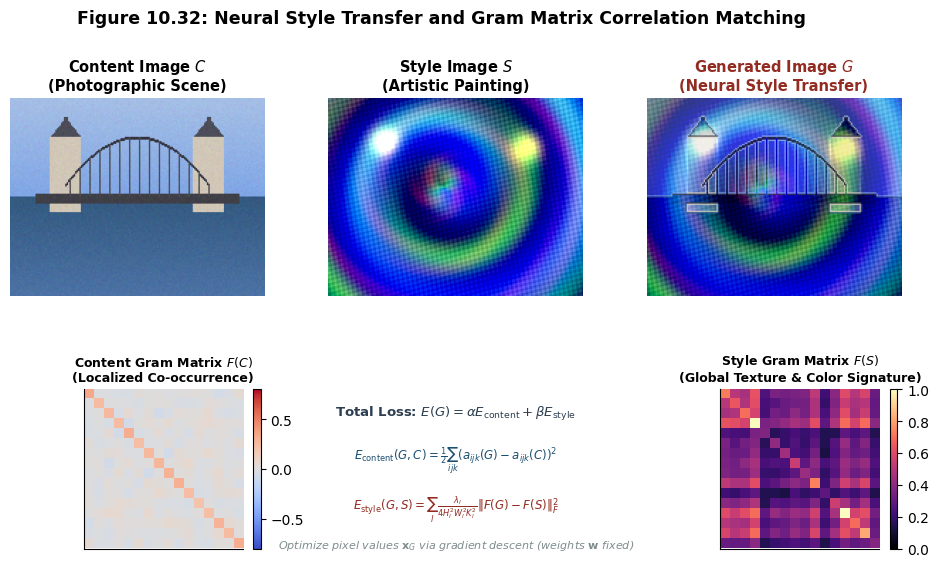

In [2]:
# 図 10.32: ニューラルスタイル変換とグラム行列による特徴相関マッチングの生成と表示
fig_10_32 = generate_figure_10_32()
plt.show()


---
## 7. 数値検証セル (Numerical Verification)

共通モジュール `common/style_transfer.py` の定式化について、以下の数学的性質を厳密に検証します：
1. **コンテンツ損失と解析的勾配の検証 (式 10.14)**:
   - 同一特徴マップに対する損失が厳密に $0$ であること。
   - 解析的勾配 $\nabla_{a(G)} E_{\mathrm{content}} = a(G) - a(C)$ が数値微分（有限差分）と $10^{-5}$ 以上の精度で一致すること。
2. **グラム行列の代数的性質 (式 10.15)**:
   - 対称性: $\mathbf{F}^\top = \mathbf{F}$。
   - 半正定値性: 全固有値 $\lambda_i \ge 0$。
   - 行列演算 $A^\top A$ による厳密な手計算値との一致。
3. **スタイル損失と解析的勾配の検証 (式 10.16)**:
   - $G = S$ において損失が $0$ となること。
   - 複層重み付け $\sum_l \lambda_l E_{\mathrm{style}}^{(l)}$ と総損失 $E(G) = \alpha E_{\mathrm{content}} + \beta E_{\mathrm{style}}$ の線形性。


In [3]:
# 1. コンテンツ損失と勾配の有限差分検証
rng = np.random.default_rng(2024)
act_G = rng.normal(0, 1, (4, 4, 3))
act_C = rng.normal(0, 1, (4, 4, 3))

# 同一テンソルに対する損失が 0
assert compute_content_loss(act_G, act_G) == 0.0

# 解析的勾配
anal_grad = compute_content_gradient(act_G, act_C)

# 数値微分 (中心差分)
eps = 1e-6
num_grad = np.zeros_like(act_G)
for i in range(act_G.shape[0]):
    for j in range(act_G.shape[1]):
        for k in range(act_G.shape[2]):
            act_p = act_G.copy()
            act_p[i, j, k] += eps
            act_m = act_G.copy()
            act_m[i, j, k] -= eps
            num_grad[i, j, k] = (compute_content_loss(act_p, act_C) - compute_content_loss(act_m, act_C)) / (2.0 * eps)

np.testing.assert_allclose(anal_grad, num_grad, rtol=1e-5, atol=1e-5)
print("✓ Content loss and gradient verified against numerical finite differences.")

# 2. グラム行列の代数的性質
K = 6
act_sample = rng.normal(0, 1, (8, 8, K))
F = compute_gram_matrix(act_sample)

# 対称性
np.testing.assert_allclose(F, F.T, err_msg="Gram matrix is not symmetric!")

# 半正定値性 (固有値 >= 0)
eigvals = np.linalg.eigvalsh(F)
assert np.all(eigvals >= -1e-10), f"Gram matrix has negative eigenvalues: {eigvals}"

# 手計算値の照合: 1x2 空間, 2 チャネル
act_small = np.array([[[1.0, 2.0], [3.0, 4.0]]])
F_small = compute_gram_matrix(act_small)
# A = [[1, 2], [3, 4]], A^T A = [[10, 14], [14, 20]]
np.testing.assert_allclose(F_small, [[10.0, 14.0], [14.0, 20.0]])
print("✓ Gram matrix symmetry, positive semi-definiteness, and exact values verified.")

# 3. スタイル損失の正規化と総損失の検証
act_S = rng.normal(0, 1, (4, 4, 3))
s_loss = compute_style_loss_layer(act_G, act_S)
assert s_loss > 0.0
assert compute_style_loss_layer(act_S, act_S) == 0.0

total, c_l, s_l = compute_total_loss(act_G, act_C, [act_G], [act_S], alpha=1.0, beta=500.0)
assert total == 1.0 * c_l + 500.0 * s_l
print(f"✓ Total Loss equation verified: Total={total:.4f}, Content={c_l:.4f}, Style={s_l:.6f}")


✓ Content loss and gradient verified against numerical finite differences.
✓ Gram matrix symmetry, positive semi-definiteness, and exact values verified.
✓ Total Loss equation verified: Total=88.2250, Content=40.6094, Style=0.095231


---
## 8. 第10章の総括と演習問題 (Exercises 10.1 〜 10.13) への展開

### 第10章「畳み込みネットワーク」全体の学びの総括
本章を通じて、コンピュータビジョンにおける深層学習の根本原理を網羅的に習得しました：
1. **10.1 コンピュータビジョン**: 画像のテンソル表現、局所空間相関減衰 $C(\Delta x)$、全結合 MLP の次元爆発と位置不変性の欠落。
2. **10.2 畳み込みフィルタ**: 相互相関演算、多チャネル $1 \times 1$ 畳み込み、プーリング、実効受容野（ERF）の線形拡大公式、VGG-16 のパラメータ・MACs 解析。
3. **10.3 CNN の可視化**: Gabor フィルタ、Zeiler & Fergus のデータセットパッチ検索、クラス活性化最大化、Grad-CAM、FGSM 敵対的攻撃、DeepDream。
4. **10.4 物体検出**: バウンディングボックス座標系、IoU 評価指標、畳み込みスライディングウィンドウの約 $3.92$ 倍の乗算回数削減、マルチスケール検出、NMS 重複抑制、R-CNN/Fast/Faster 系譜。
5. **10.5 画像セグメンテーション**: 画素単位分類と mIoU、SegNet のスイッチ変数付き最大アンプーリング、転置畳み込み（分数ストライド畳み込み）と行列転置双対性、U-net のスキップ結合による意味情報と空間位置の融合。
6. **10.6 スタイル変換**: 学習済み特徴マップの内積によるグラム行列、空間不変なテクスチャ相関の抽出、コンテンツ・スタイル二重目的関数によるピクセル最適化。

### 次のステップ：第10章 演習問題 (Exercises 10.1 〜 10.13)
これまでに獲得した全理論と数学的定式化を基に、教科書巻末に収録されている **全13問の演習問題 (Exercises 10.1 〜 10.13)** の完全な理論証明、穴埋め・選択式検証、および Python 自己採点アサーション実装へと進みます。
